In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

from file_reading import pd_read_exp_file
import data_locs as LOCS
import lorentz_fit as lorentz
import plotting

## **Experiment B**

In [2]:
# lowest_harmonic = 274.25448868690813
lowest_harmonic = 125

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 1.0, 'current_temp': 69.980430186, 'current_temp_err': 0.00211013261159623, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 3}


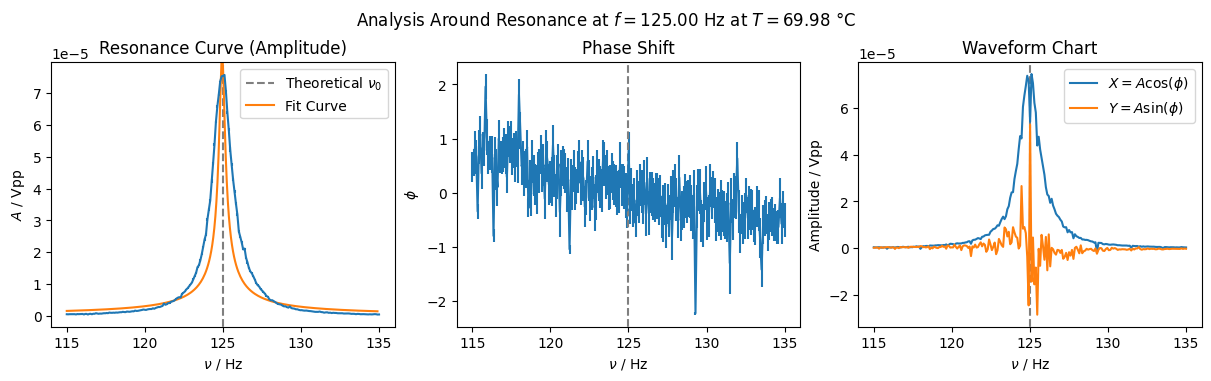

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.8888888888888888, 'current_temp': 72.00790907400004, 'current_temp_err': 0.0008845575174610274, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


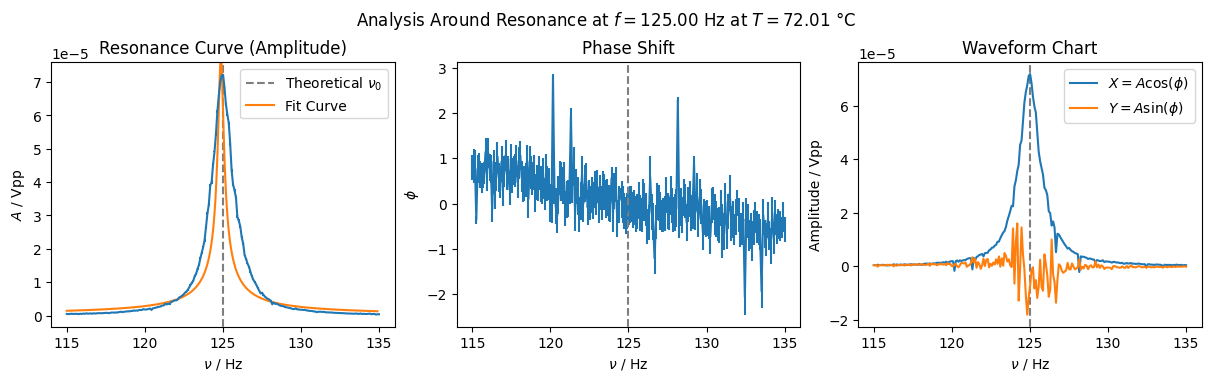

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.7777777777777777, 'current_temp': 73.80723177, 'current_temp_err': 0.0, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 1}


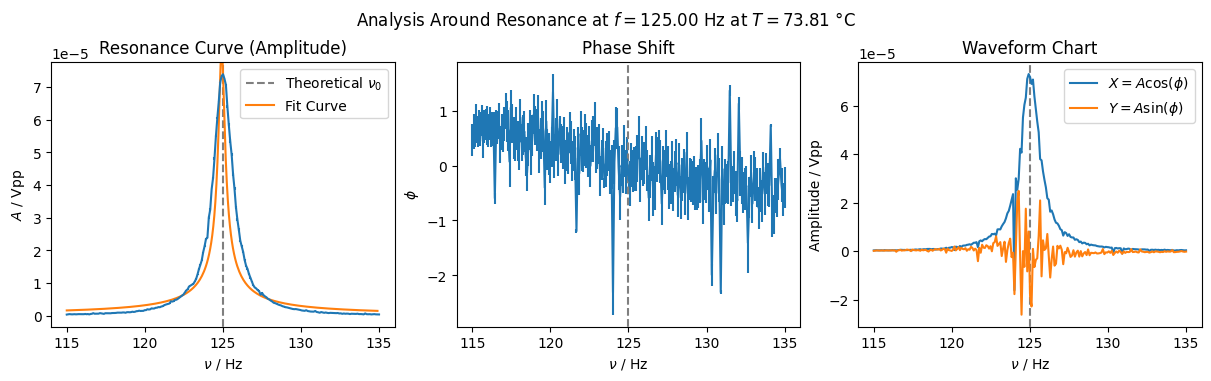

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.6666666666666666, 'current_temp': 73.80723177, 'current_temp_err': 0.0, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


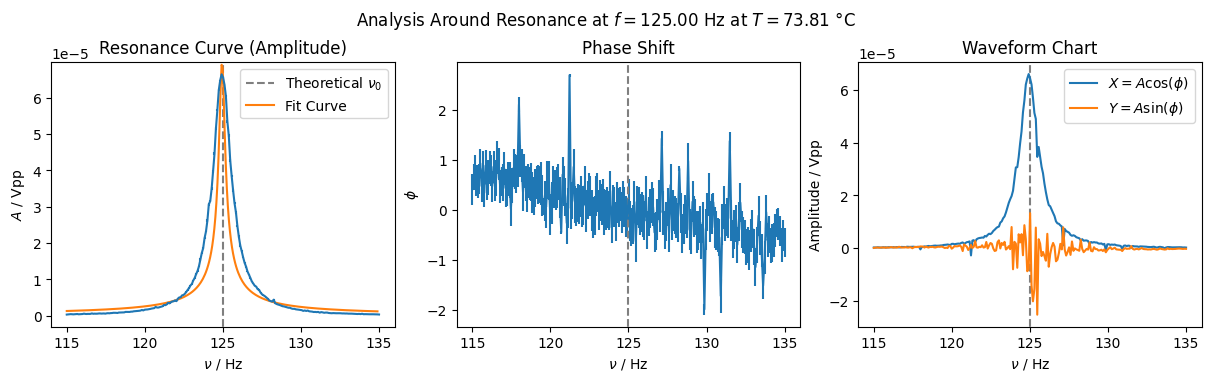

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.5555555555555556, 'current_temp': 69.91302040200001, 'current_temp_err': 0.0005159376016774748, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


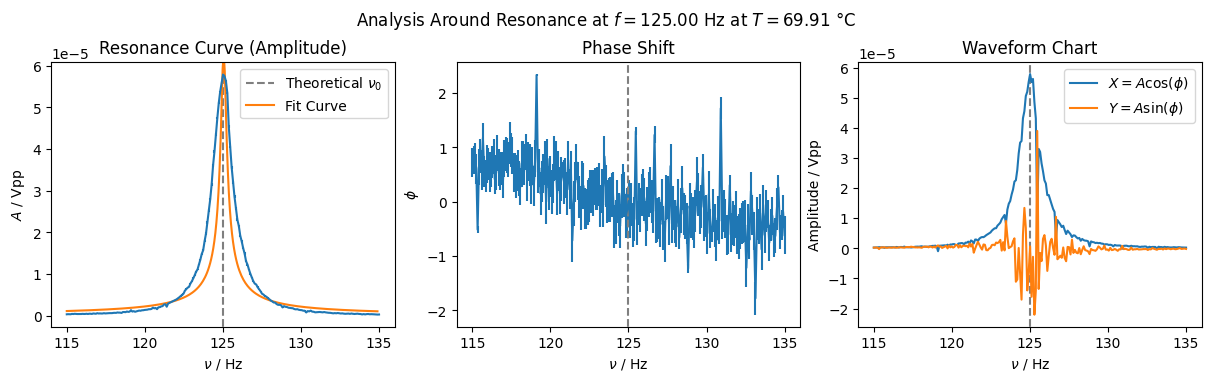

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.4444444444444444, 'current_temp': 62.783139402000046, 'current_temp_err': 0.0030562895062528073, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


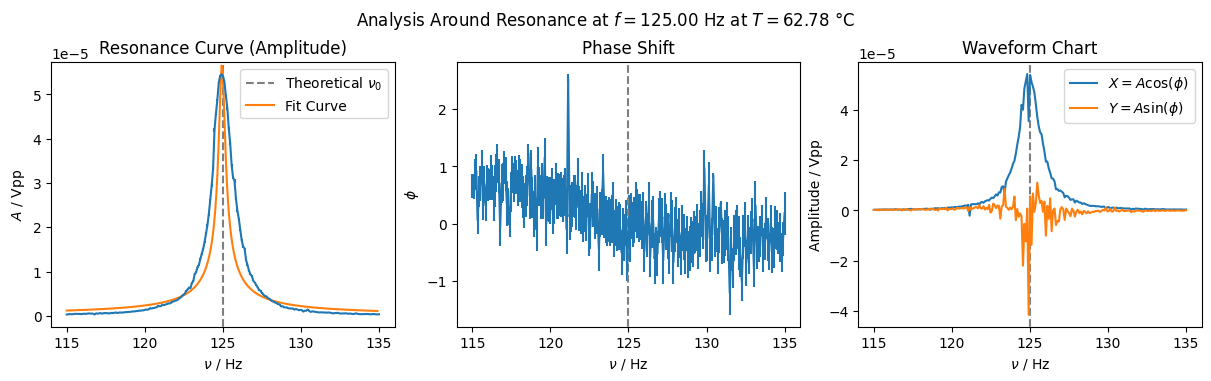

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.3333333333333333, 'current_temp': 55.775114550000055, 'current_temp_err': 0.002777320083574138, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


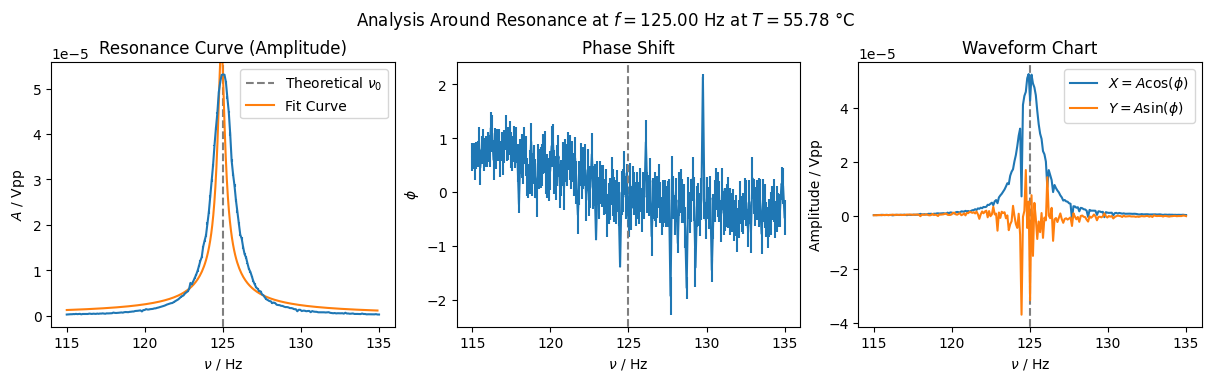

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.2222222222222222, 'current_temp': 49.18451182200002, 'current_temp_err': 0.000773906402516233, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


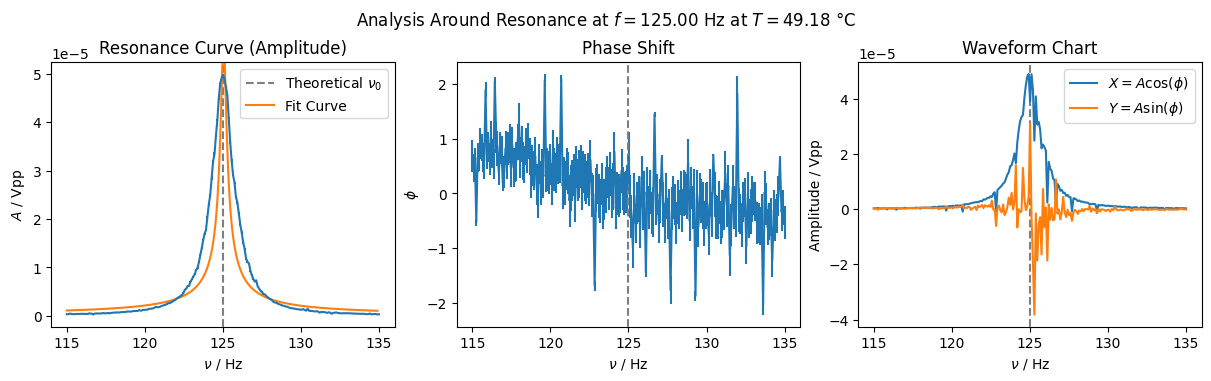

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.1111111111111111, 'current_temp': 42.695023770000034, 'current_temp_err': 7.105427357601002e-17, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 1}


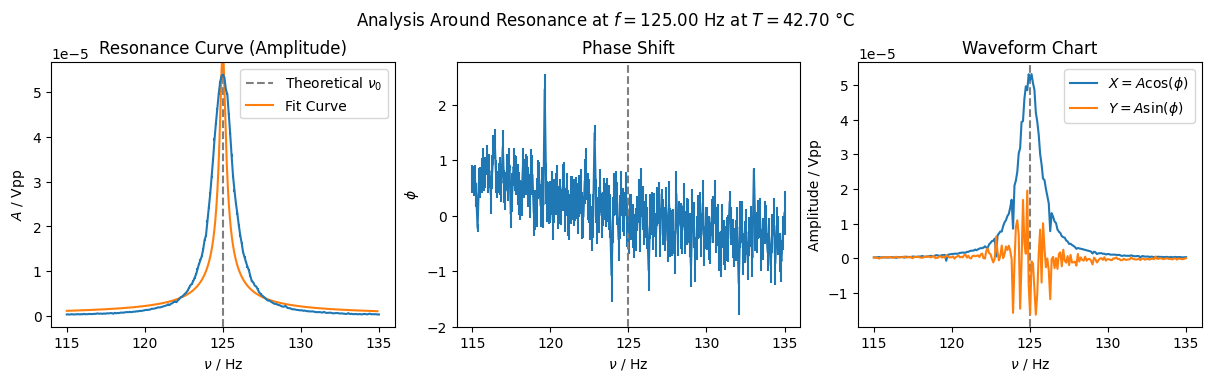

{'trials': 20, 'sleeptime': 0.9, 'target_voltage': 0.0, 'current_temp': 38.82933192599999, 'current_temp_err': 0.0013268362761916135, 'current_temp_gradient': 0.0, 'loops_to_stabilize_temperature': 0}


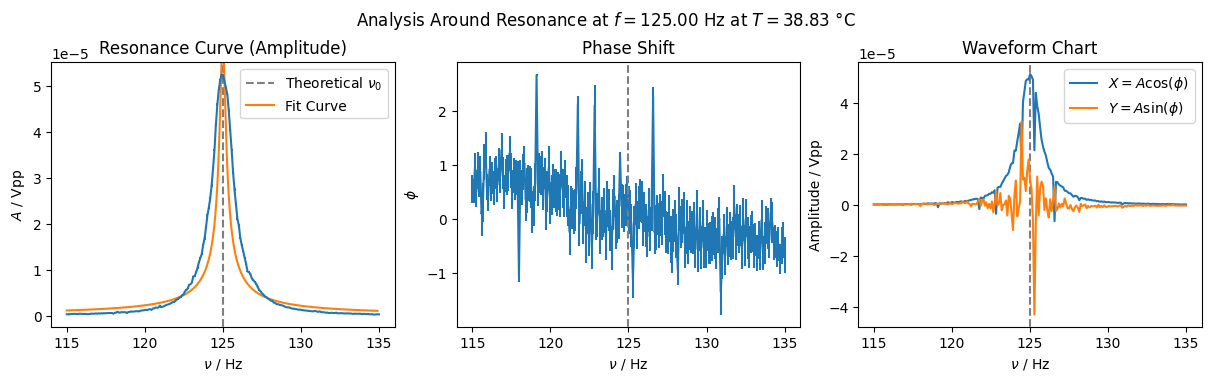

In [3]:
locs = LOCS.final.expB[1]

fitparam_results: list[dict] = []

for i, loc in enumerate(locs):
    data, metadata = pd_read_exp_file(loc)
    print(metadata)
    temp = metadata["current_temp"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plotting.pd_freq_spectrum(fig, axs, data)
    for ax in axs:
        plotting.vertical_line(ax, lowest_harmonic, label=r"Theoretical $\nu_0$")

    result_dict = {"current_temp": metadata["current_temp"], 'target_freq': lowest_harmonic, "target_voltage": metadata.get("target_voltage")}
    min_idx, max_idx = (20, -20)
    min_idx, max_idx = (0, -1)
    result_dict = result_dict | lorentz.do_fit(axs[0], data["freq"][min_idx:max_idx], data["A"][min_idx:max_idx], data["A_err"][min_idx:max_idx])
    fitparam_results.append(result_dict)

    axs[0].legend()
    fig.suptitle(f"Analysis Around Resonance at $ f = {lowest_harmonic:.2f}$ Hz at $ T = {temp:.2f} $ °C")
    plt.show()

In [4]:
expB_df = pd.DataFrame(fitparam_results)
df = pd.DataFrame(fitparam_results)
df.pop('params_list')
df.pop('params_err_list')

display(df)

,current_temp,target_freq,target_voltage,f_0,f_0_err,omega_0,omega_0_err,gamma,gamma_err,fit_Q_factor,fit_Q_err
0,69.980430,125,1.000000,0.144301,0.000278,785.095445,0.004224,2.235523,0.005978,351.190926,6.527221e+07
1,72.007909,125,0.888889,0.133713,0.000253,784.593449,0.004662,-2.176237,0.006232,-360.527561,-6.067875e+07
2,73.807232,125,0.777778,0.153149,0.000234,784.905712,0.002893,2.387211,0.005279,328.796186,8.920137e+07
3,73.807232,125,0.666667,0.123689,0.000228,785.050551,0.003862,-2.254945,0.005132,-348.146262,-7.076665e+07
4,69.913020,125,0.555556,0.109847,0.000198,785.710270,0.003325,2.217834,0.005405,354.269253,8.372357e+07
5,62.783139,125,0.444444,0.111377,0.000194,785.025970,0.003811,-2.492909,0.005095,-314.903574,-6.487098e+07
6,55.775115,125,0.333333,0.120769,0.000170,784.768945,0.003371,-2.575988,0.005652,-304.647776,-7.093104e+07
7,49.184512,125,0.222222,0.103194,0.000179,785.668194,0.004161,2.329066,0.006443,337.331907,6.369354e+07
8,42.695024,125,0.111111,0.106739,0.000187,785.337405,0.003396,2.292620,0.005550,342.550181,7.921392e+07
9,38.829332,125,0.000000,0.110328,0.000183,785.340987,0.003842,-2.348225,0.006114,-334.440303,-6.836540e+07


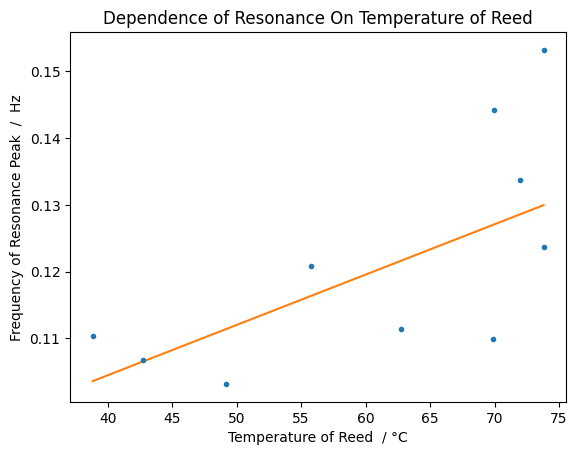

Temperature Coefficient: 0.0007543430168119805 ± 5.076551579470997e-06


In [5]:
fig, ax = plt.subplots()
ax.errorbar(expB_df["current_temp"], expB_df["f_0"], yerr=expB_df["f_0_err"], linestyle="", marker='.')

params, pcov = curve_fit((lambda x, m, c: m * x + c), expB_df["current_temp"], expB_df["f_0"], sigma=expB_df["f_0_err"], absolute_sigma=True)
params_err = np.sqrt(np.diag(pcov))

xspace = np.linspace(np.min(expB_df["current_temp"]), np.max(expB_df["current_temp"]), 50)
ax.plot(xspace, params[0] * xspace + params[1])

ax.set_xlabel("Temperature of Reed  / °C")
ax.set_ylabel("Frequency of Resonance Peak  /  Hz")
ax.set_title("Dependence of Resonance On Temperature of Reed")

plt.show()

print(f"Temperature Coefficient: {params[0]} ± {params_err[0]}")

In [6]:
# part b
# fit each spectrum (g.o.f.)
# resonance frequencies against temp plot
# linear regression fit
# slope = temp coeff
# vorzeichen der steigung

